# tspropy Mask Processing Tutorial

This tutorial introduces the mask-processing utilities in **tspropy**.

A boolean mask is often the natural result of a time-series condition, for example `Total Site Load > 8 MW`. On its own, however, a mask describes individual observations rather than the continuous operating phases formed by consecutive `True` values.

`tspropy` provides utilities for turning these masks into meaningful phases. Once phases have been identified, they can be used to calculate phase-level quantities such as energy and duration, and to filter phases according to operational criteria.

The examples below build this workflow step by step.

# 1. Mask Processing

## 1.1 Why process masks as phases?

Consider the following condition:

```python
mask = df["Total Site Load"] > 8
```

If the condition is true for twenty consecutive observations, those observations usually represent **one high-consumption phase**, not twenty independent events.

This distinction matters in operational time-series analysis. A phase can have properties of its own:

- start and end time,
- duration,
- energy consumption,
- average or peak value,
- and other statistics.

The mask-processing utilities in `tspropy` make this phase structure explicit while remaining compatible with normal pandas operations.

## 1.2 The mask-processing workflow

The examples in this tutorial follow four steps:

1. Create a boolean mask from a time-series condition.
2. Convert consecutive `True` values into phase numbers.
3. Calculate phase-level properties using pandas.
4. Use phase duration to identify phases of interest.

This approach combines the simplicity of boolean masks with the analytical power of phase-based time-series processing.

# 2. Dataset

## 2.1 Energy time-series example

The tutorial uses `load_and_price.csv`, the same energy dataset used in the plotting examples.

The dataset covers **one week of operation** and is sampled at **5-minute resolution**. For this tutorial, the relevant variable is `Total Site Load`, representing the electrical demand of the site in MW.

A five-minute sampling interval is useful for phase analysis because a continuous operating state is represented by a sequence of observations rather than a single point.

The condition used throughout the tutorial is:

```text
Total Site Load > 8 MW
```

This gives us a realistic example of detecting and analysing periods of high electrical consumption.

## 2.2 Load the dataset

In [ ]:
import pandas as pd

from src.data_manipulation.core.basic.mask_processing.mask_properties import (
    get_mask_phase_durations,
    get_mask_phase_numbers,
)
from src.custom_objects.plotter_objects import (
    Axes,
    Color,
    ColorMapper,
    Labels,
    MaskRange,
    RangeConfig,
    RangePropertyName,
    YLimits,
)
from src.data_visualisation.plotting_funcs import plot_datetime_data

df = pd.read_csv(
    r"../../../data/load_and_price.csv",
    index_col="datetime",
    parse_dates=True,
)

# 3. Create a Boolean Mask

## 3.1 Define the operating condition

We start by identifying periods where the site load exceeds 8 MW.

The result is a boolean Series. `True` indicates that the condition is satisfied at that timestamp; `False` indicates that it is not.

At this stage, the mask contains only point-by-point information. The next section will turn consecutive `True` values into phases.

In [5]:
mask_high_consumption = df["Total Site Load"] > 8  # MW

## 3.2 Visualize the original signal

Before analysing the mask, it is useful to see the underlying load signal.

In [4]:
site_load_color = Color.RED
fig1 = plot_datetime_data(
    df=df[["Total Site Load"]],
    labels=Labels(y1_label="Load in MW"),
    y_limits=YLimits(y1_limit=[5, 10]),
    color_mapper=ColorMapper("Total Site Load", site_load_color),
    title="Total Site Load Overview",
)

> *Total Site Load over the selected week, with the Y-axis focused on the 5–10 MW range.*
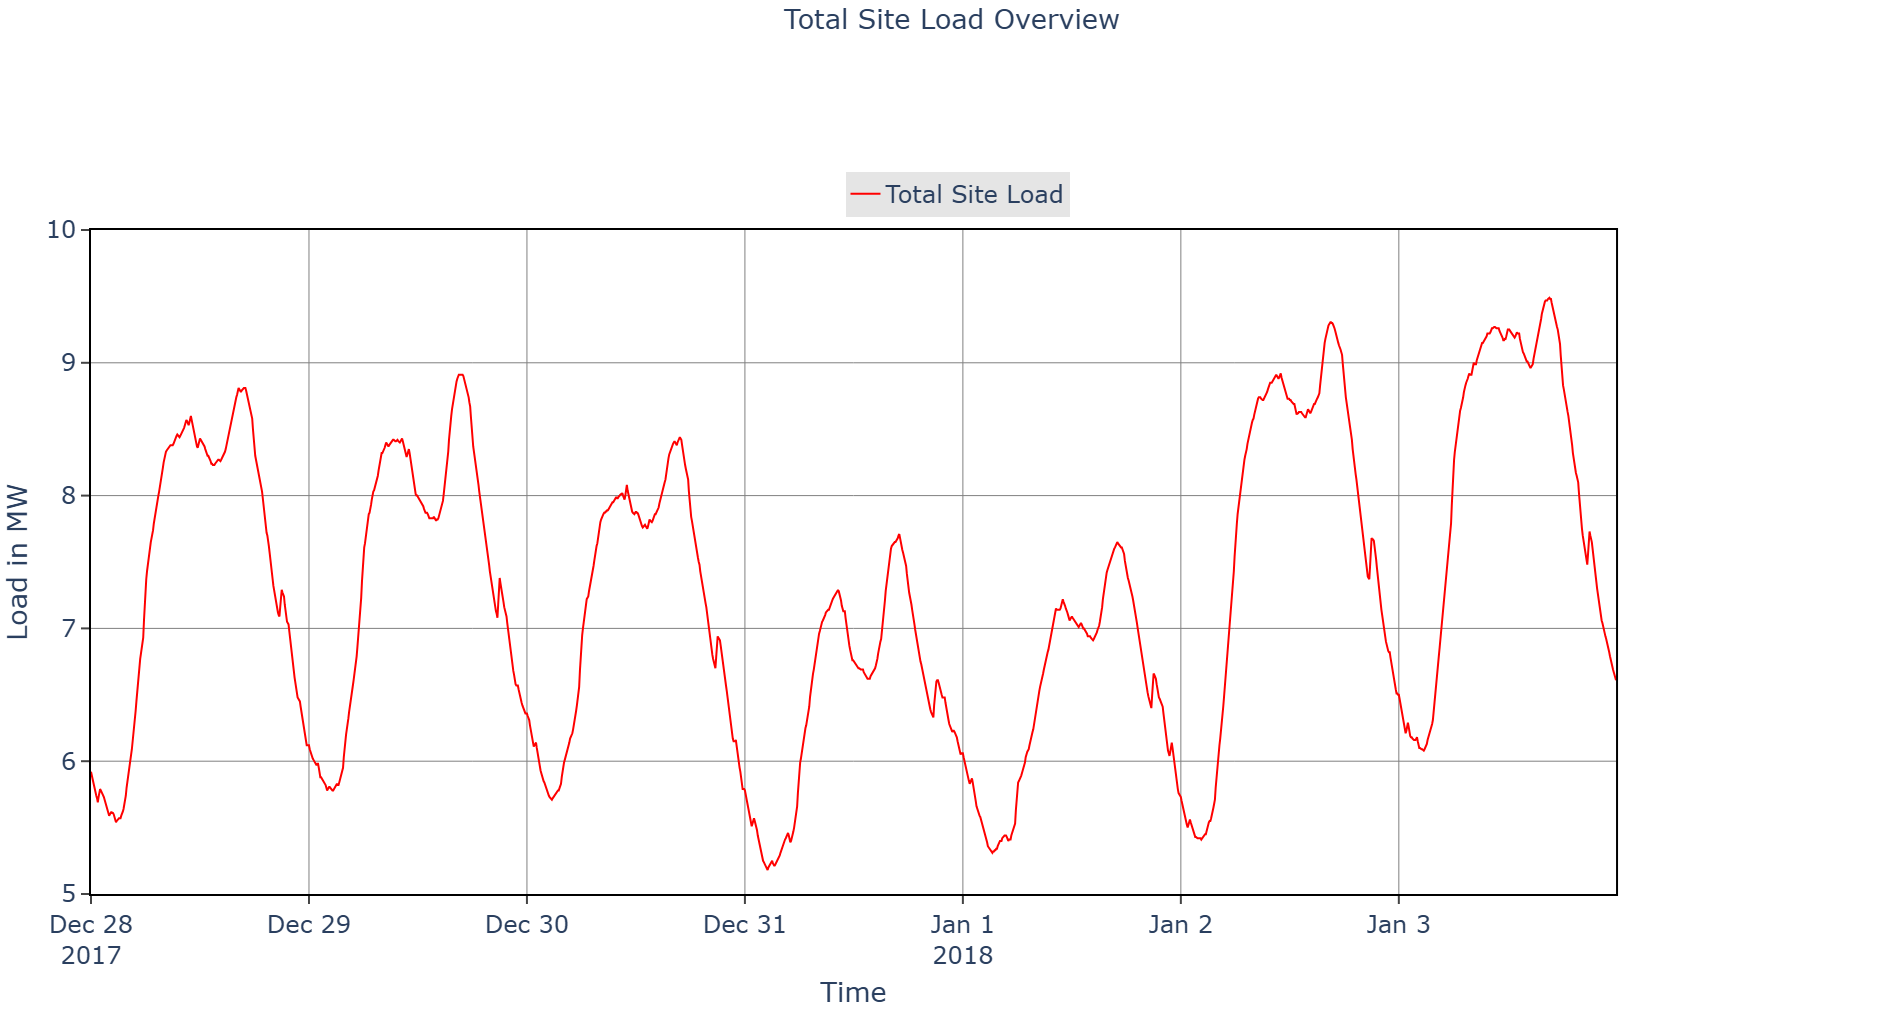

# 4. `get_mask_phase_numbers`

## 4.1 From observations to phases

`get_mask_phase_numbers` assigns a positive identifier to each consecutive `True` phase in a boolean mask, while it
assigns a negative identifier to each consecutive `False` phase.

With this technique, we are controlling not only the `True` phases, but also `False` phases in one go.

Conceptually:

```text
False False True True True False True True False False
 └─────┘      └───────┘     └─┘   └─────┘    └─────┘
 Phase -1      Phase 1   Phase -2  Phase 2   Phase -3
```

The resulting phase numbers can then be passed directly to pandas operations such as `groupby`.

This is the key transition from **row-level conditions** to **phase-level analysis**.

In [6]:
high_consumption_phase_nr = get_mask_phase_numbers(
    mask=mask_high_consumption,
)

## 4.2 Calculate energy for each phase

The dataset is sampled every five minutes. For a power value in MW, the energy represented by one observation is:

```text
Power [MW] × 5 min / 60 min = Energy [MWh]
```

We can therefore calculate the energy consumed during each phase (low consumption phases and high consumption phases
at once) and use `transform` to assign that phase-level result back to every observation belonging to the phase.

In [7]:
data_freq_in_min = 5
min_in_h = 60

calculate_energy = lambda power: sum(power * data_freq_in_min / min_in_h)

df["Phase Energy"] = df.groupby(
    high_consumption_phase_nr
)["Total Site Load"].transform(func=calculate_energy)

## 4.3 Visualize phase-based energy consumption

We can now plot the original load together with the phase-level energy.

The load is assigned to the first Y-axis and phase energy to a second Y-axis. The high-consumption phases are highlighted using the same colour as the phase-energy curve.

In [ ]:
energy_color = Color.PURPLE
fig2 = plot_datetime_data(
    df=df,
    axes=Axes(y1="Total Site Load", y2="Phase Energy"),
    labels=Labels(y1_label="Load in MW", y2_label="Energy in MWh"),
    color_mapper=[
        ColorMapper("Total Site Load", site_load_color),
        ColorMapper("Phase Energy", energy_color),
    ],
    range_config=RangeConfig(
        range_type=MaskRange(range=mask_high_consumption),
        property={RangePropertyName.COLOR: energy_color},
    ),
    title="Phase-Based Energy Consumption",
)

> *Total Site Load with high-consumption phases highlighted and their phase-level energy shown on a secondary Y-axis.*
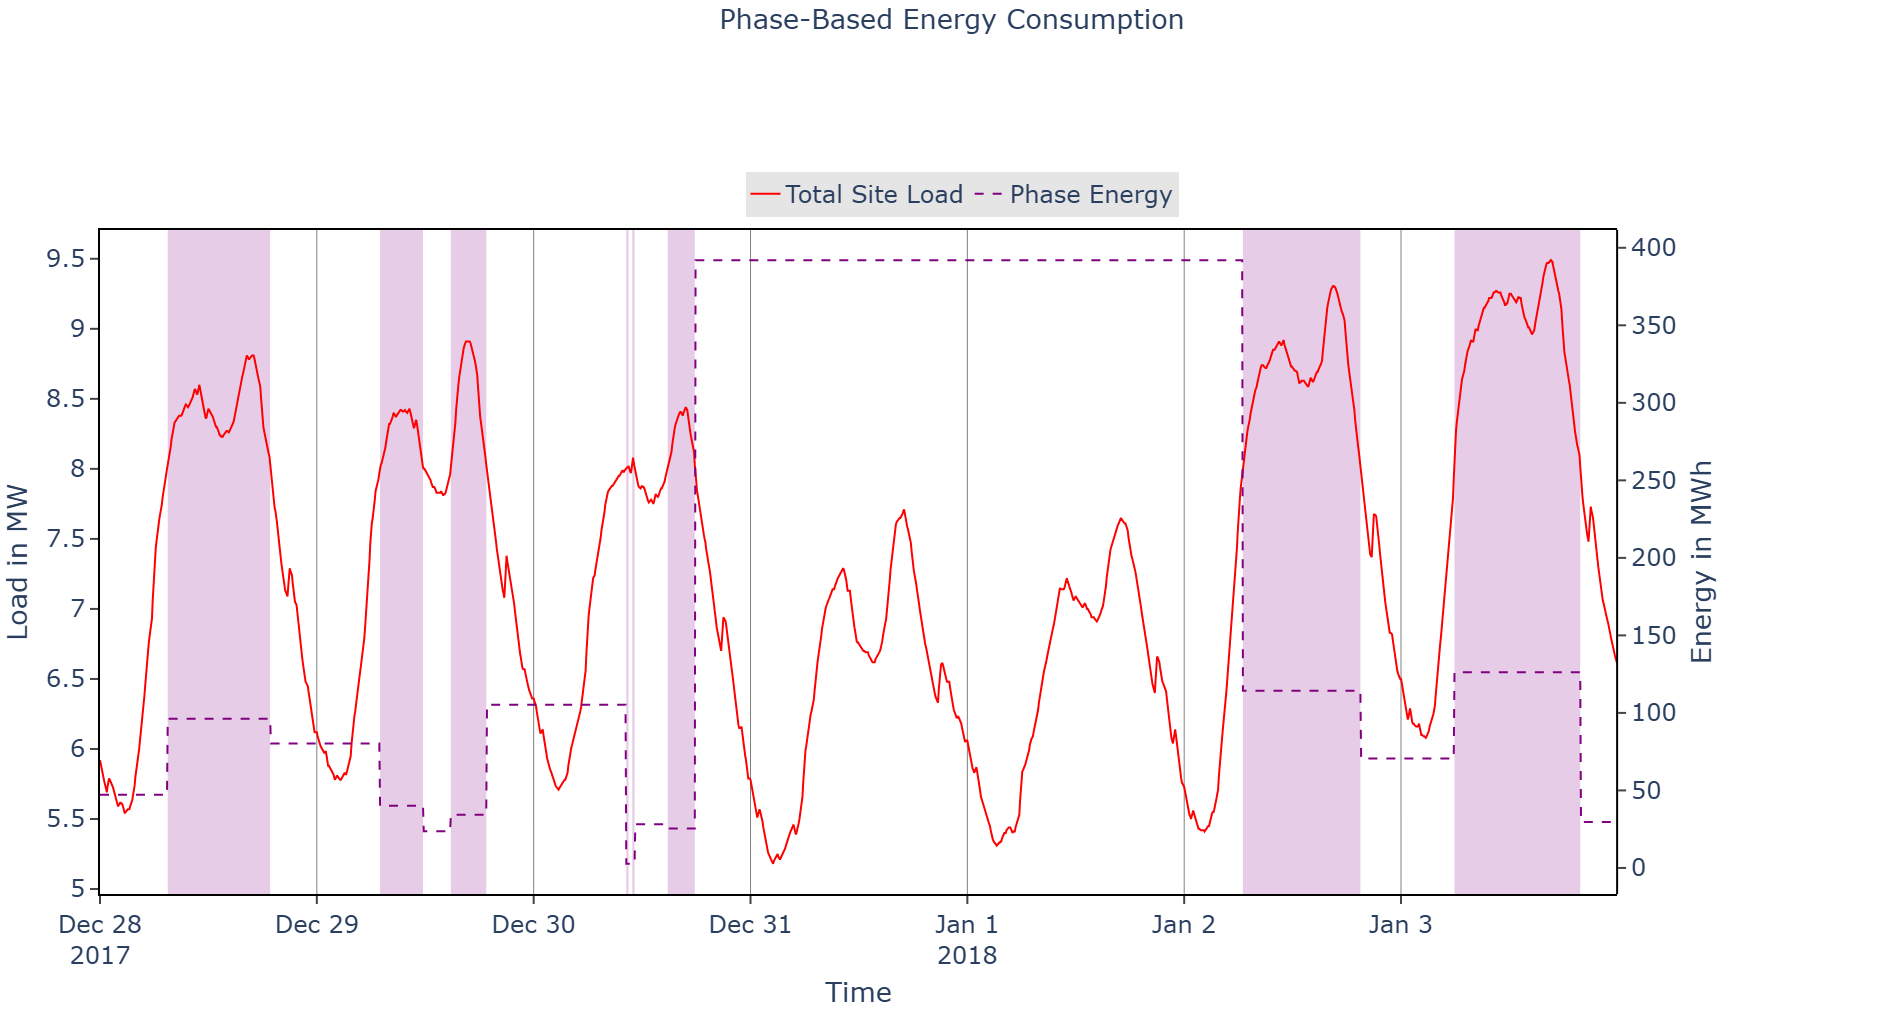
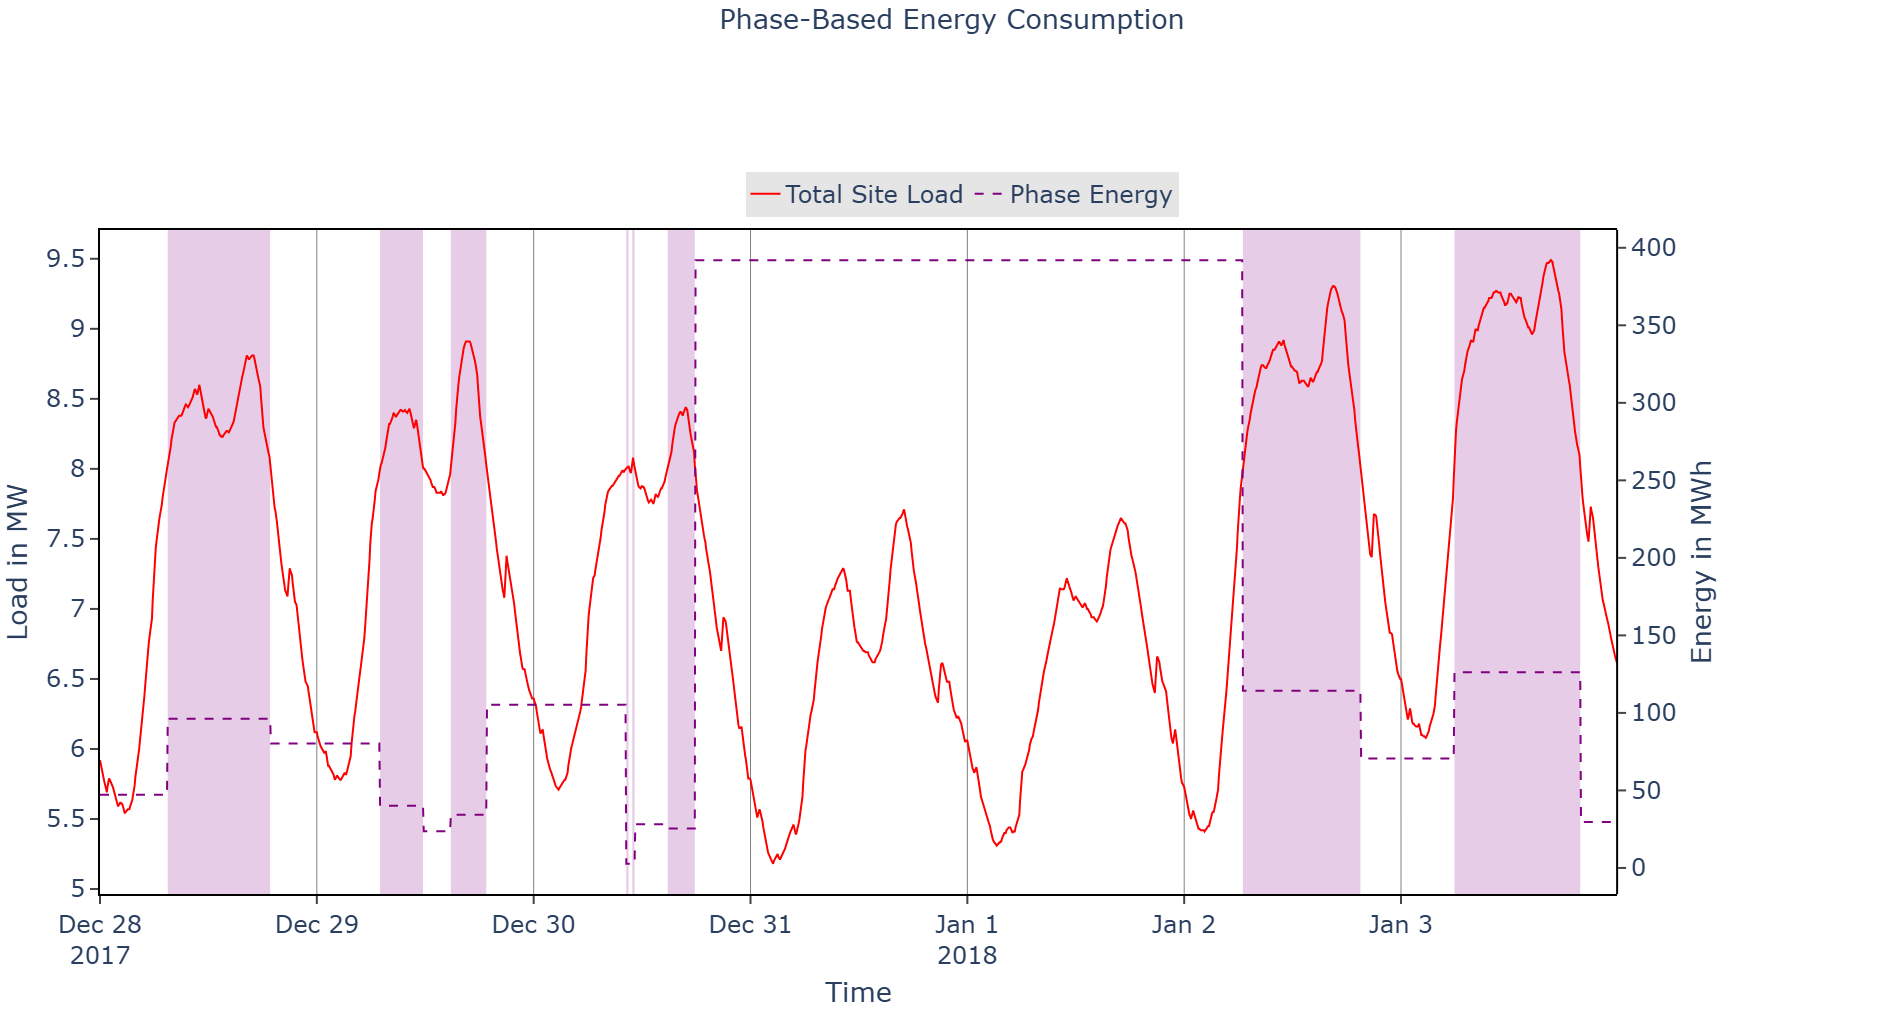

The boolean mask has now been transformed into a meaningful operational quantity: the energy associated with each high-consumption phase.

The next question is whether all of these phases are equally relevant. Often they are not. A short excursion above a threshold may be less important than a condition that persists for several hours.

# 5. `get_mask_phase_durations`

## 5.1 Determine phase duration

`get_mask_phase_durations` calculates the duration represented by the phases in a boolean mask.

Phase duration is particularly useful for operational filtering. Instead of asking only whether a threshold was exceeded, we can ask whether it was exceeded for a meaningful amount of time.

In [8]:
load_phase_durations = get_mask_phase_durations(
    mask=mask_high_consumption,
)

## 5.2 Filter phases by duration

In this example, we are interested only in high-consumption phases lasting **more than two hours**.

The phase durations can therefore be converted into another boolean mask:

In [9]:
mask_long_phases = load_phase_durations > pd.Timedelta("2h")

`mask_long_phases` now identifies the observations belonging to phases whose duration exceeds two hours.

This illustrates an important advantage of phase-based processing: a condition derived from the **properties of a complete phase** can be converted back into a time-aligned mask and used with the original DataFrame.

## 5.3 Visualize the filtered phases

The new mask can be passed directly to `MaskRange` so that only the long high-consumption phases are highlighted.

In [ ]:
fig3 = plot_datetime_data(
    df=df,
    axes=Axes(y1="Total Site Load", y2="Phase Energy"),
    labels=Labels(y1_label="Load in MW", y2_label="Energy in MWh"),
    color_mapper=[
        ColorMapper("Total Site Load", site_load_color),
        ColorMapper("Phase Energy", energy_color),
    ],
    range_config=RangeConfig(
        range_type=MaskRange(range=mask_long_phases),
        property={RangePropertyName.COLOR: energy_color},
    ),
    title="Phase-Based Energy Consumption (Only Long Phases)",
)

> *Only high-consumption phases lasting more than two hours are highlighted.*
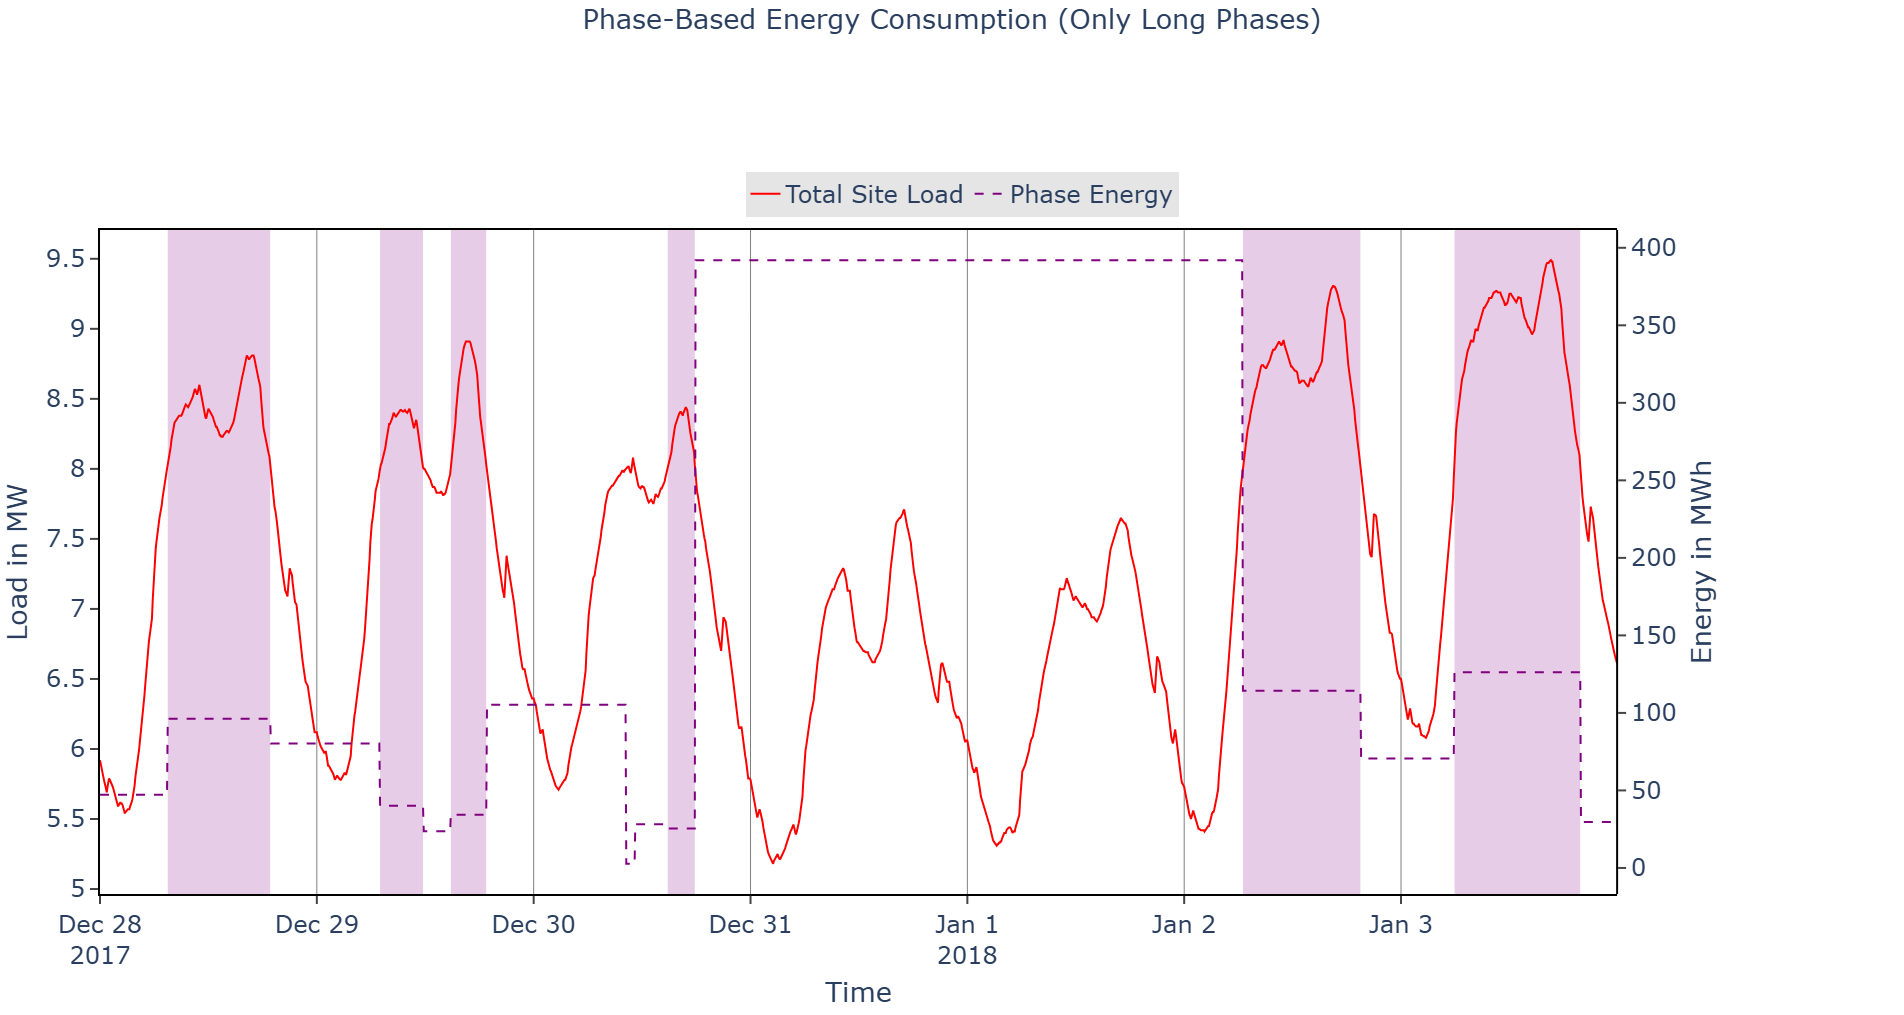
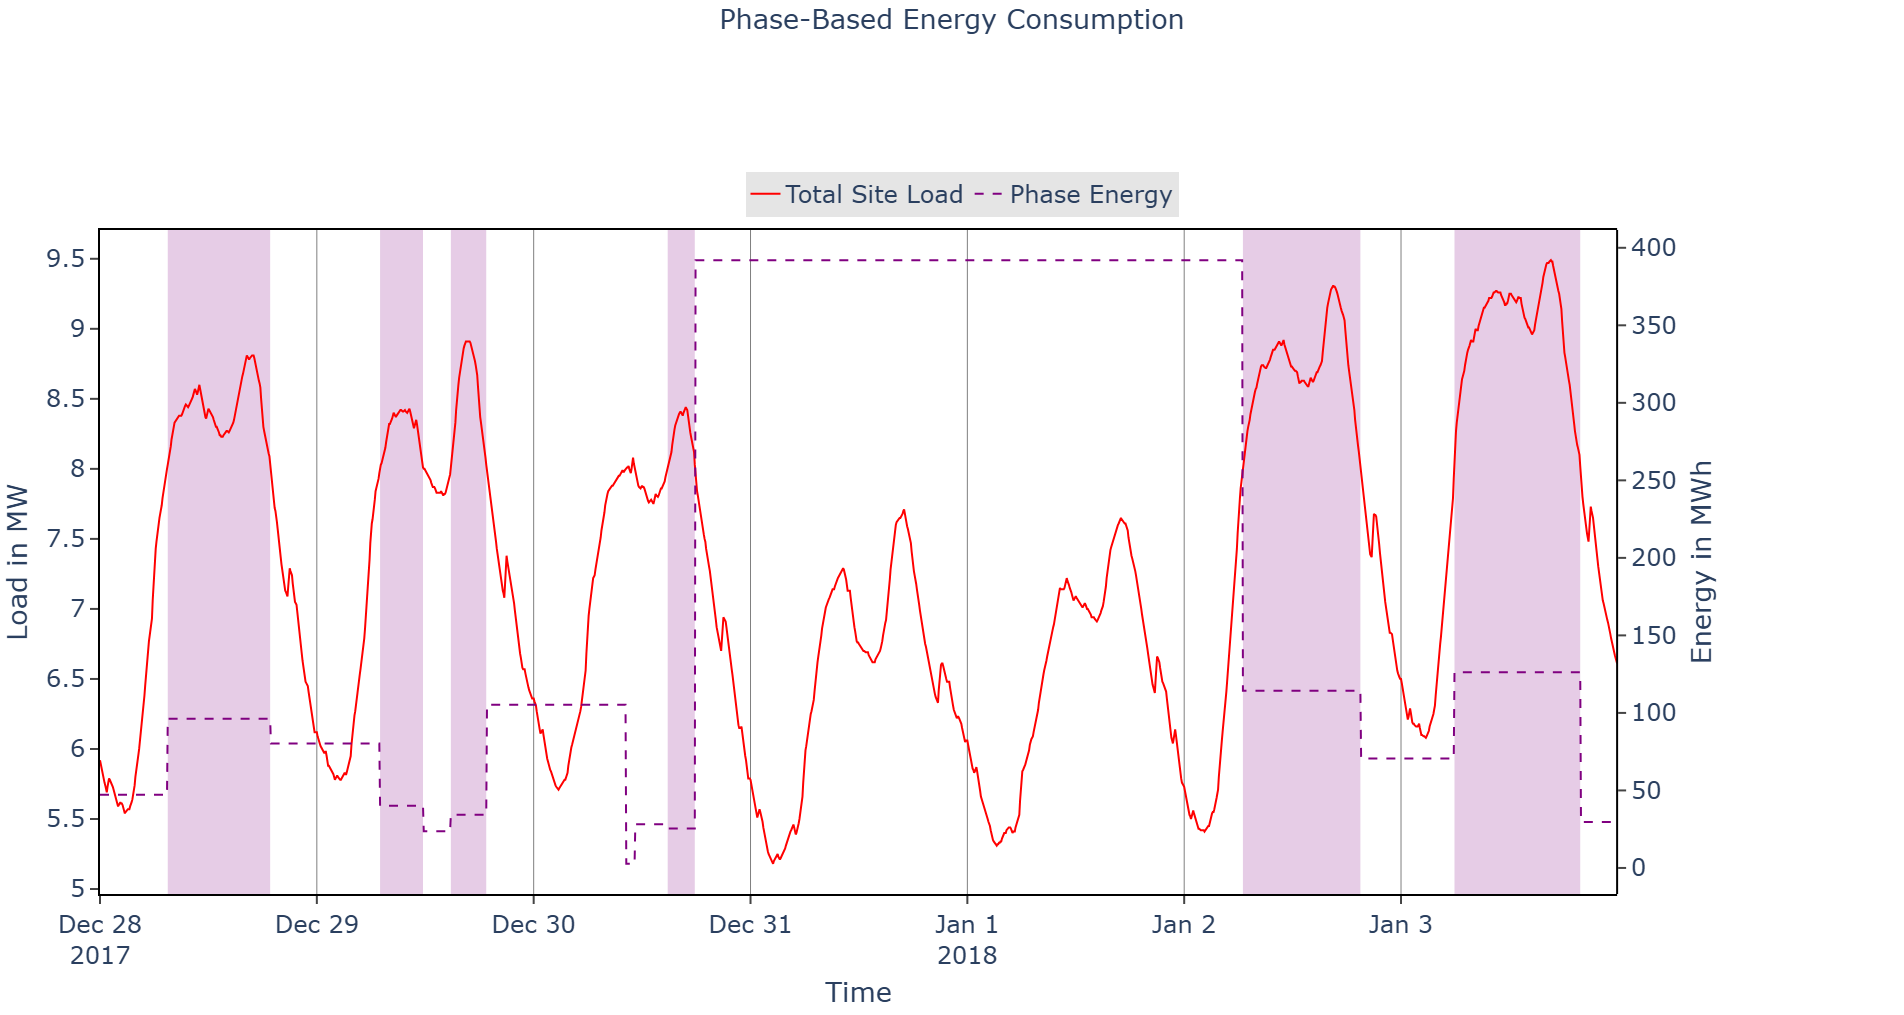

The final visualization communicates considerably more information than the original threshold mask. It distinguishes sustained high-consumption phases from short excursions above the threshold.

The general pattern is:

```text
condition
    ↓
boolean mask
    ↓
phase numbers
    ↓
phase properties
    ↓
phase-based filtering
    ↓
time-series visualization
```

# 6. tbd